# Plot polar maps of boreal domain data 
Paul Montesano  
Fall 2022  
run this notebook in a conda R env

In [1]:
#system("conda activate r-with-gdal")

In [1]:
library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)

library(rgeos)
library(mapproj)
#library(rgee)
library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)
library(terra)
#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

Loading required package: sp

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks raster::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks raster::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, 

# Paths of final tindex master files

## Set output figure dir.

In [2]:
MAINDIR = '/projects/my-public-bucket/tte_map'
OUT_FIGURE_DIR = paste0(MAINDIR, '/daac_figs')
OUT_DATA_DIR = paste0(MAINDIR, '/data')

### Mapping functions and vars

In [3]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


#### Note: the ability to make these maps is changing...

The use of type 'SpatialPolygons' will go away.  
This means 'crop' will need to be changed to crop an 'sf' object.

But the whole polar mapping function is built around the use of 'SP', not 'sf'.-  

THis will need work and testing to be able to reproduce these polar maps.

At the moment, these still works in `r-env-3.6.3` on Prism

In [4]:
# Circ map new: trying to combine the best of the sf and sp approaches
DO_MAP_BOREAL_SP <- function( MAP_EXTENT = extent(-180,180,45,90), xlim=NULL, ylim=NULL, rotate_map=0, proj_name = 'azequalarea', LAYER_LIST=NULL, 
                             BOREAL_SHP_FN = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'){
  #
  # Map with a polar projection
  #
  
  # Color scale help
  #https://biostats.w.uib.no/color-scale-for-continuous-variables/
  
  #source(path("C:\\Users\\pmontesa\\Google Drive\\Work\\R","plot_functions.R"))
  # Shapefiles
  
  
  #world <- crop(ne_countries(scale = "medium", returnclass = "sp"), MAP_EXTENT)
  world <- raster::crop(as(ne_countries(scale = "medium", returnclass = "sf"), 'Spatial'), MAP_EXTENT)
  #world = st_crop(x = ne_countries(scale = "medium", returnclass = "sf") %>% st_make_valid() ,  y = ext)
  
  # WWF
  #boreal <- shp_fort_join("D:\\databank\\wwf\\arc\\wwf_circumboreal_Dissolve.shp", MAP_EXTENT, REPROJECT = TRUE)
  # TerraPulse
  boreal <- shp_fort_join(boreal_shp_fn, MAP_EXTENT, REPROJECT = TRUE)
  
  map_list_base = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill="grey90", color=NA),
    geom_polygon(data = boreal, aes(x = long, y = lat, group = group), color=NA, fill="grey70"))
    
  map_list_top = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill=NA, color="black", size=0.1 ),
    
    theme_minimal() , 
    theme(axis.text = element_blank(), axis.title = element_blank() ) ,
    
    #geom_polygon(data = fortify(continents.df_stereo), aes(x = long, y = lat, group = group), fill = NULL, colour = "black", size=0.25) +
    #scale_color_distiller(palette = "Greens", direction = 1, name = "%"),
    #scale_color_manual(values = COLOR_PAL, name = map_str) ,
    guides(guide = guide_legend(direction = "horizontal", nrow=1, label.position = "bottom", title.position = "bottom") ) ,
    theme(legend.position="top",
          legend.title = element_text(size=9),
          #       legend.direction  = 'vertical',
          legend.key.width  = unit(1.0, "cm"),
          legend.key.height = unit(.25, "cm")  )
  )
  
  if(is.null(LAYER_LIST)){
    map_list = list(
      map_list_base,
      map_list_top
    )
  }else{
    map_list = list(
      map_list_base,
      LAYER_LIST,
      map_list_top
    )
  }
  
  p_map = ggplot() + map_list +
    #coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map, xlim = xlim, ylim = ylim)
    coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map)
  
  if(FALSE){
    out_plot_fn = paste0("D:/projects/3dsi/plots/map_boreal_",proj_name,"_", format(Sys.time(), "_%Y%m%d"),'.png')
    print(out_plot_fn)
    ggsave(plot = p_map ,
           file = out_plot_fn,
           device = 'png', dpi = 300, width = 5, height = 5)
  }
  #print(p_map)
  return(p_map)
  
}

coord_map_stereo_list <- function(proj_name = "stereo", rotation = 0, min_lat = 50, xlims=NULL, ylims=NULL, LABEL_SIZE=3){ 
  
  # Defines the x axes required
  lat_lines = seq(min_lat+10, 80, by = 10)
  lat_labs = paste0(seq(min_lat+10, 80, by = 10), "\u00B0N")
  
  lon_lines = seq(0, 330, by = 30)
  lon_labs = c("0", paste0(seq(30, 150, by = 30), "°E"), "180", rev(paste0(seq(30, 150, by = 30), "°W")))
  
  
  return(list(
    # Convert to polar coordinates
    coord_map(proj_name, orientation = c(90, 0, rotation, xlims=xlims, ylims=ylims)), #"ortho""
    scale_y_continuous(breaks = seq(45, 90, by = 5), labels = NULL),
    
    # Removes Axes and labels
    scale_x_continuous(breaks = NULL),
    xlab(""),
    ylab(""),
    
    # Adds axes
    # Latitude
    geom_hline(aes(yintercept = lat_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    # Outer circular border
    geom_hline(aes(yintercept = min_lat), size = 0.25), #1
    # Longitude
    geom_vline(aes(xintercept = lon_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    #geom_segment(aes(y = 45, yend = 85, x = x_lines, xend = x_lines), linetype = "dotted") +
    
    # Adds labels
    #geom_text(aes(x = 0, y = lat_lines, hjust = 0.5, label = lat_labs)),
    geom_label(aes(x = 0, y = lat_lines, label = lat_labs), label.size = NA, size=LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),
    #geom_text(aes(x = lon_lines, y = min_lat-3, hjust = 0.5, vjust = 0.5, label = lon_labs), size = 2.5), #hjust = 0.5
    # min-3 so lon labels are centered over outer line
    geom_label(aes(x = lon_lines, y = min_lat-3, label = lon_labs), label.size = NA,  hjust='inward', vjust='inward', size = LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),  #y = min_lat-3 why used to be this?
    
    ##guides(fill=FALSE)+
    
    # Change theme to remove axes and ticks
    theme(panel.background = element_blank(),
          #panel.grid = element_line(size = 0.25, linetype = 'dotted', colour = "grey50"),
          axis.ticks=element_blank())
    #,
    #labs(caption = "Source: circ_tte_map.Rmd")
  ))
}  

gridCreate<-function(shp, res,proj_out, buffer=10000){
  
  if (!is.null(buffer)){
    shp<-buffer(shp, width=buffer)
  }
  ext <- floor(extent(shp))
  rr <- raster(ext, res=res)
  rr <- rasterize(shp, rr, field=1)
  rr[!is.na(rr[])]<-1:length(rr[!is.na(rr[])])
  grid<-rasterToPolygons(rr)
  crs(grid)<-projection(shp)
  if (!proj_out==projection(shp)){
    grid<-spTransform(grid,CRS(proj_out))
  }
  return(grid)  
}



In [5]:
crs_canalb = "+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"
crs_albers = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
crs_gcs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"

### Get Boreal EXTENT

#### Read boreal extent, read tiles, then clip tiles to boreal extent

In [6]:
boreal_shp_fn = '/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson'
boreal = st_read(boreal_shp_fn)
boreal_albers<-spTransform(sf:::as_Spatial(boreal),CRS(crs_albers))

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson' 
  using driver `GeoJSON'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -164.95 ymin: 44.39544 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


#### Get all tiles delivered to DAAC for this project

In [7]:
tte_tiles_DAAC_path = '/projects/shared-buckets/montesano/databank/tte_tiles.gpkg'
tiles_gcs_DAAC = st_read(tte_tiles_DAAC_path) %>% st_transform(4326)
tile_num_DAAC_list =  tiles_gcs_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
tile_num_DAAC_list = unlist(tile_num_DAAC_list[[1]])
length(tile_num_DAAC_list)

Reading layer `tte_tiles' from data source 
  `/projects/shared-buckets/montesano/databank/tte_tiles.gpkg' 
  using driver `GPKG'
Simple feature collection with 4809 features and 4 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180.0004 ymin: 45.00014 xmax: 179.9998 ymax: 75.00014
Geodetic CRS:  WGS 84


[1] 4809

#### Clip tiles to Boreal EXTENT

In [8]:
# boreal_tile_index_path = '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg'
# boreal_tiles_clip = st_intersection(
#                                 st_read(boreal_tile_index_path) %>% st_transform(crs="+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"), 
#                                 boreal)#%>% as.data.frame()

## Map showing boreal tile extent

In [9]:
ext = extent(-180,180,45,90)

In [10]:
#boreal_tiles_gcs = shp_fort_join(boreal_tile_index_path, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson' 
  using driver `GeoJSON'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -164.95 ymin: 44.39544 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”
Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Regions defined for each Polygons


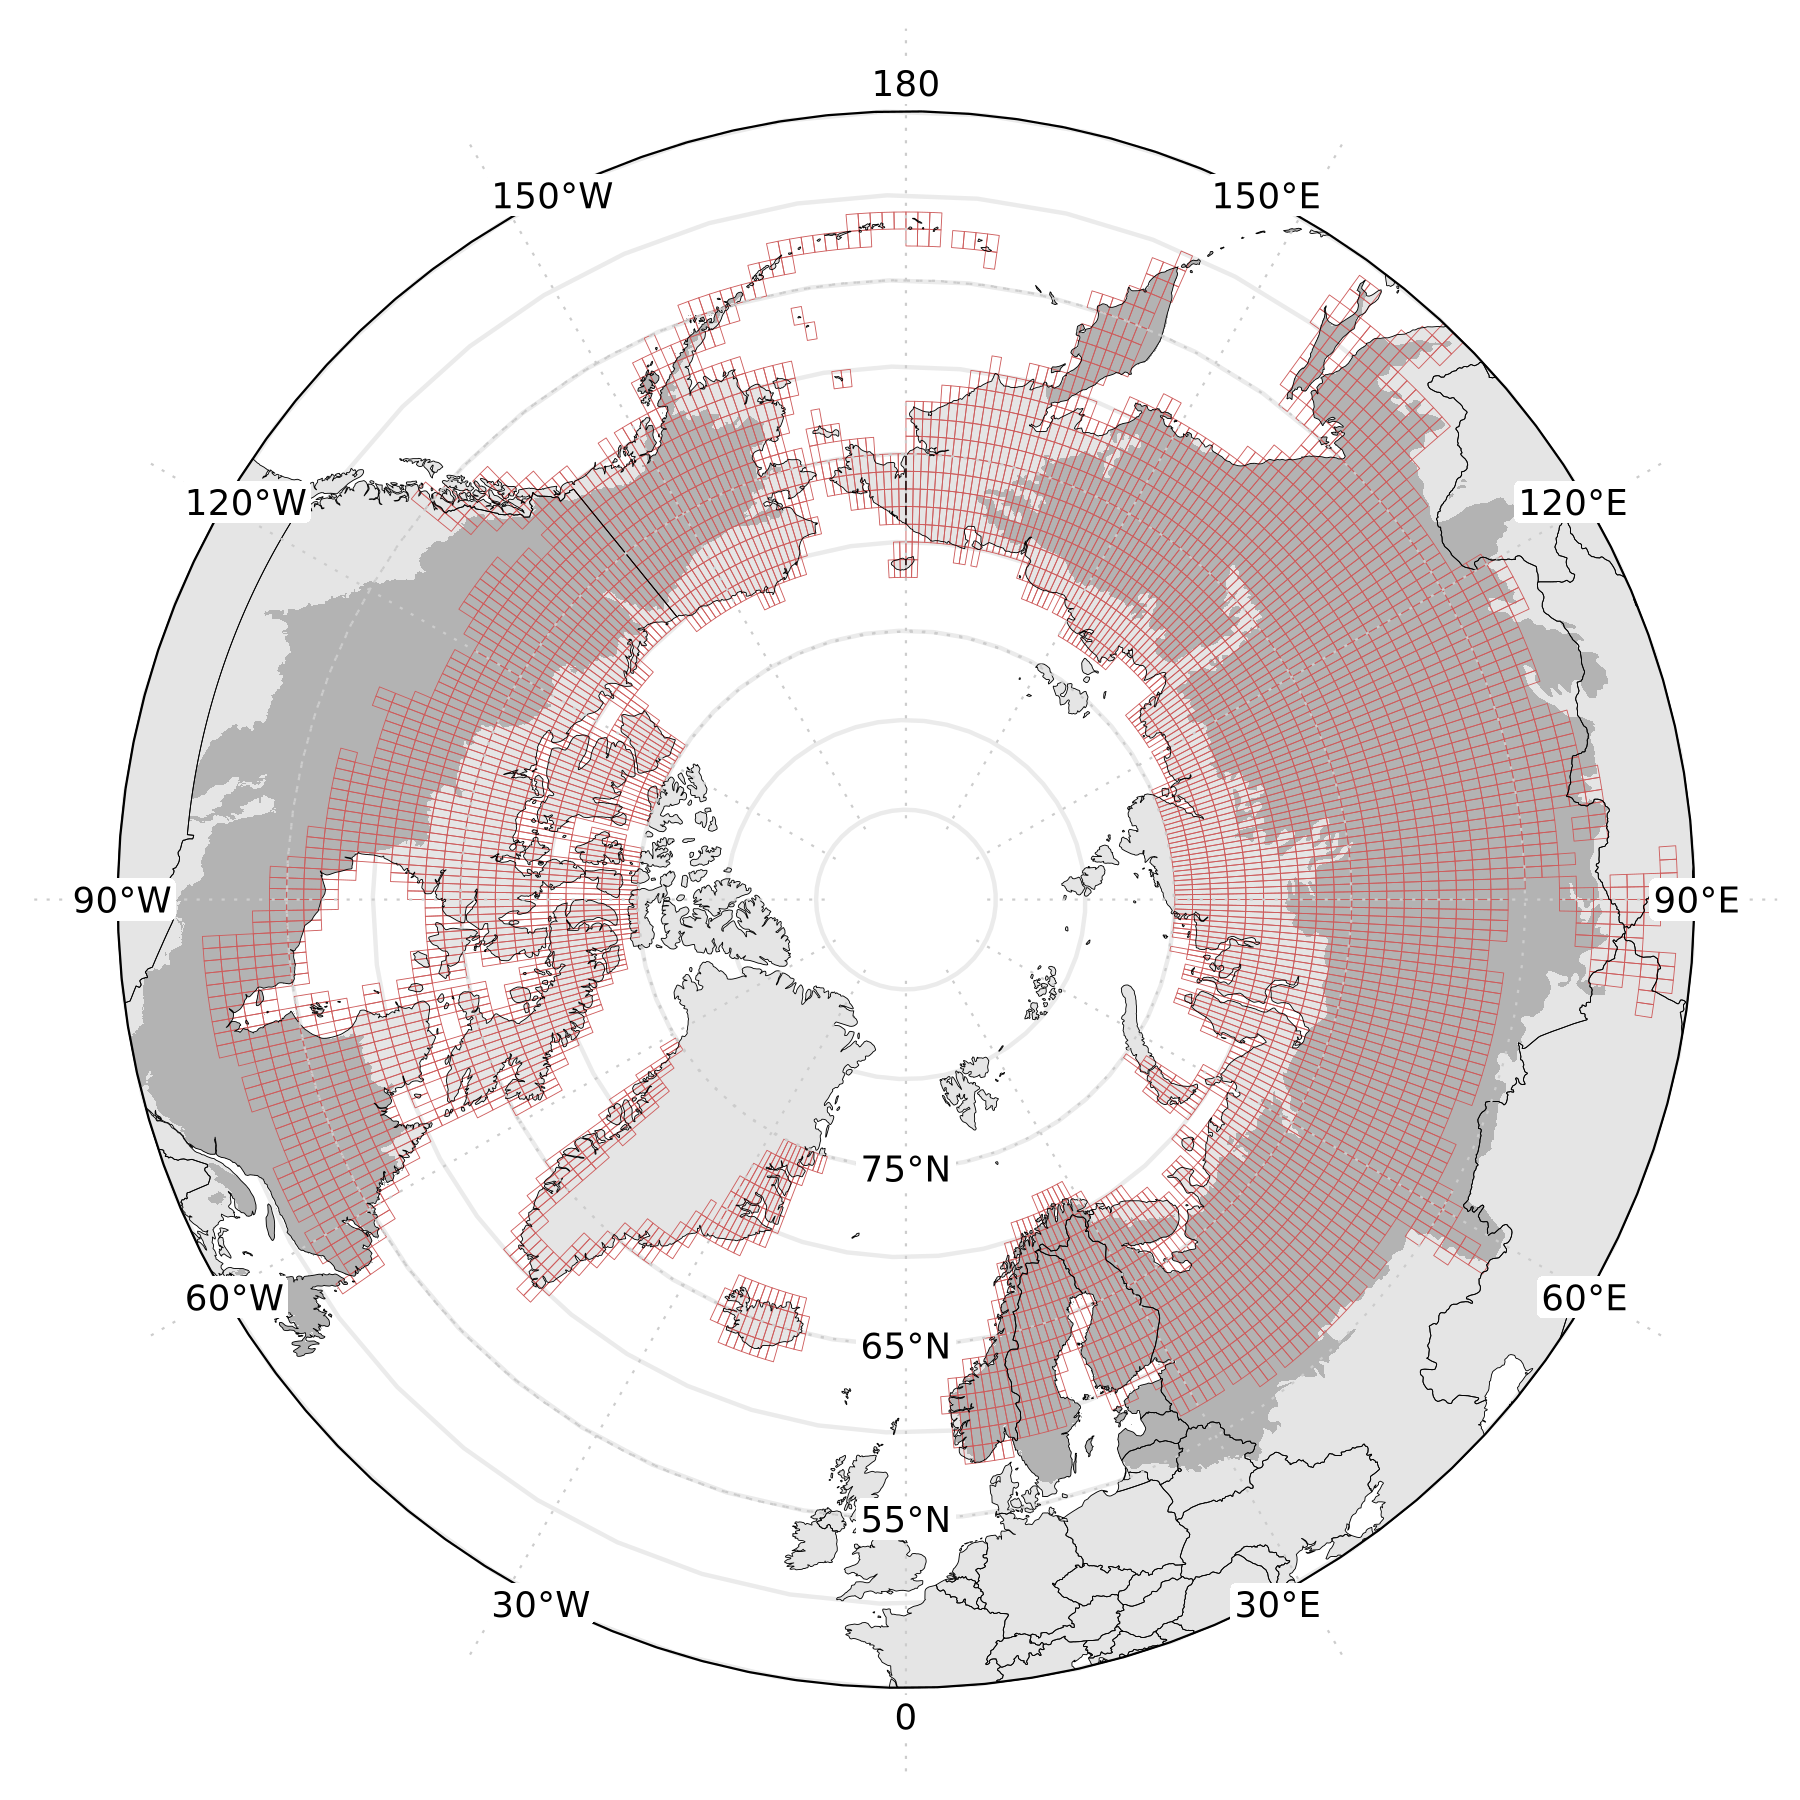

In [11]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 300)

m_tte_tiles = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90),  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(geom_polygon(data = fortify_sf(tiles_gcs_DAAC %>% dplyr::filter(tile_num %in% tile_num_DAAC_list)), 
                                                    aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='indian red')
                                      ) #, fill=NA
                    ) + 
    theme(legend.text=element_text(size=rel(0.5))) #+
    #scale_color_brewer(palette = 'Set2') +
    #scale_fill_viridis_d() +
    #guides(fill=guide_legend(title="Tile groups", title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.25, "cm"), nrow=2))
m_tte_tiles

## Export figure: DAAC tiles - all tiles for c2020 map

In [15]:
DATA_NAME_STEM = "tte_tiles_DAAC"
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")

for(OUT_TYPE in c('png', 'pdf')){
    map_fn = path(OUT_FIGURE_DIR, paste0("map_",DATA_NAME_STEM,"_", EXPORT_TIME_STR,".", OUT_TYPE))
    print(map_fn)
    ggsave(plot = m_tte_tiles, create.dir = TRUE,
           file = map_fn,
           device = OUT_TYPE, dpi = 300, width = 8, height = 15)
}

/projects/my-public-bucket/tte_map/daac_figs/map_tte_tiles_DAAC__20251116.png
/projects/my-public-bucket/tte_map/daac_figs/map_tte_tiles_DAAC__20251116.pdf


In [37]:
# Choose a TTE mosiac at some COARSE RESOLUTION
raster_path = '/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_6tiles_0p007500.tif'
raster_path = '/projects/my-public-bucket/local_output/TTEmap_3000/TTEmap_3000_classification_mosaic.tif'
raster_path = '/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_4809tiles_0p007500.tif'
raster_path = '/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_4809tiles_0p010000.tif'
RASTER_DF_NAMES = c('x','y','tte_classes')
raster_path

[1] "/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_4809tiles_0p010000.tif"

In [38]:
raster_read_proj_convert <- function(fn, DF_NAMES = c('x','y','value')){
    
    raster_proj <- rast(fn)    
    r <- project(raster_proj, "EPSG:4326")
    
    # # Check CRS and basic info
    # print(r)
    
    # Convert raster to data frame
    r_df <- as.data.frame(r, xy = TRUE)
    
    names(r_df) = DF_NAMES

    return (r_df)
    }
# Create the named classification vector
tte_classes_dict <- c(
  "1" = "Sparse & Abrupt",
  "2" = "Sparse & Diffuse-rapid", 
  "3" = "Sparse & Diffuse-gradual    ",
  "4" = "Sparse & Uniform",
  "5" = "Open & Uniform",
  "6" = "Open & Diffuse-gradual    ",
  "7" = "Open & Diffuse-rapid", 
  "8" = "Open & Abrupt",
  "9" = "Intermediate & Closed    ",
  "10" = "Non-forest edge (dry)",
  "11" = "Non-forest edge (wet)"
)

# Create the color palette vector (matching your original colors)
tte_colors_dict <- c(
  "1" = "#5255a3",   # Sparse & Abrupt
  "2" = "#1796a3",   # Sparse & Diffuse-rapid
  "3" = "#fdbf6f",   # Sparse & Diffuse-gradual
  "4" = "#ff7f00",   # Sparse & Uniform
  "5" = "#ffffbf",   # Open & Uniform
  "6" = "#d9ef8b",   # Open & Diffuse-gradual
  "7" = "#91cf60",   # Open & Diffuse-rapid
  "8" = "#1a9850",   # Open & Abrupt
  "9" = "#c4c4c4",   # Intermediate & Closed
  "10" = "#ff0000",  # Non-forest edge (dry)
  "11" = "#0000ff"   # Non-forest edge (wet)
)

In [40]:
r_df = raster_read_proj_convert(raster_path, DF_NAMES = RASTER_DF_NAMES) %>% 
    filter(tte_classes != '-Inf') %>%
    #mutate(tte_classes = round(r_df$tte_classes,0)) %>%
    filter(tte_classes != 9) #%>% # remove Intermediate Forest for plotting
   # mutate(tte_classes <- factor(r_df$tte_classes))
dim(r_df)

[1] 9670026       3

In [ ]:
head(r_df)

In [19]:
# Using geom_tile instead of geom_raster was key to this working...

In [55]:
tte_layers = list(
    geom_tile(data = r_df, mapping = aes(x = x, y = y, fill = factor(tte_classes))),
    scale_fill_manual(values = tte_colors_dict, labels = tte_classes_dict,
                   name = "Taiga-tundra ecotone\nforest structure\npattern classification",
                   na.value = "transparent"),
    guides(fill = guide_legend(
        nrow = 11,          # 2 rows to accommodate 11 classes in ~6 columns each
        ncol = 1,          # 6 columns
        byrow = FALSE,      # Fill by rows first
        title.position = "top",
        title.hjust = 0,
        label.position = "right",
        #override.aes = list(size = 3)  # Make legend keys more visible
        )
          ),
    theme(
        #legend.position = c(0.98, 0.97),
        legend.position = 'right',
        #legend.justification = c("right", "top"),
        legend.direction = "horizontal",
        legend.title = element_text(size = 12
                                    #, face = "bold"
                                    , hjust = 0.5),
        legend.text = element_text(size = 8),
        #legend.key.size = unit(0.35, "cm"),
        legend.key.width = unit(0.35, "cm"),
        legend.key.height = unit(0.35, "cm"),
        legend.box = "horizontal",
        # # Increase spacing between legend items
        # legend.spacing.x = unit(5.75, "cm"),  # Horizontal spacing between items
        # legend.spacing.y = unit(0.01, "cm"),  # Vertical spacing between rows
        # Add overall margin to the legend
        #legend.margin = margin(t = 5, r = 5, b = 5, l = 5)
        )
                    )

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson' 
  using driver `GeoJSON'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -164.95 ymin: 44.39544 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


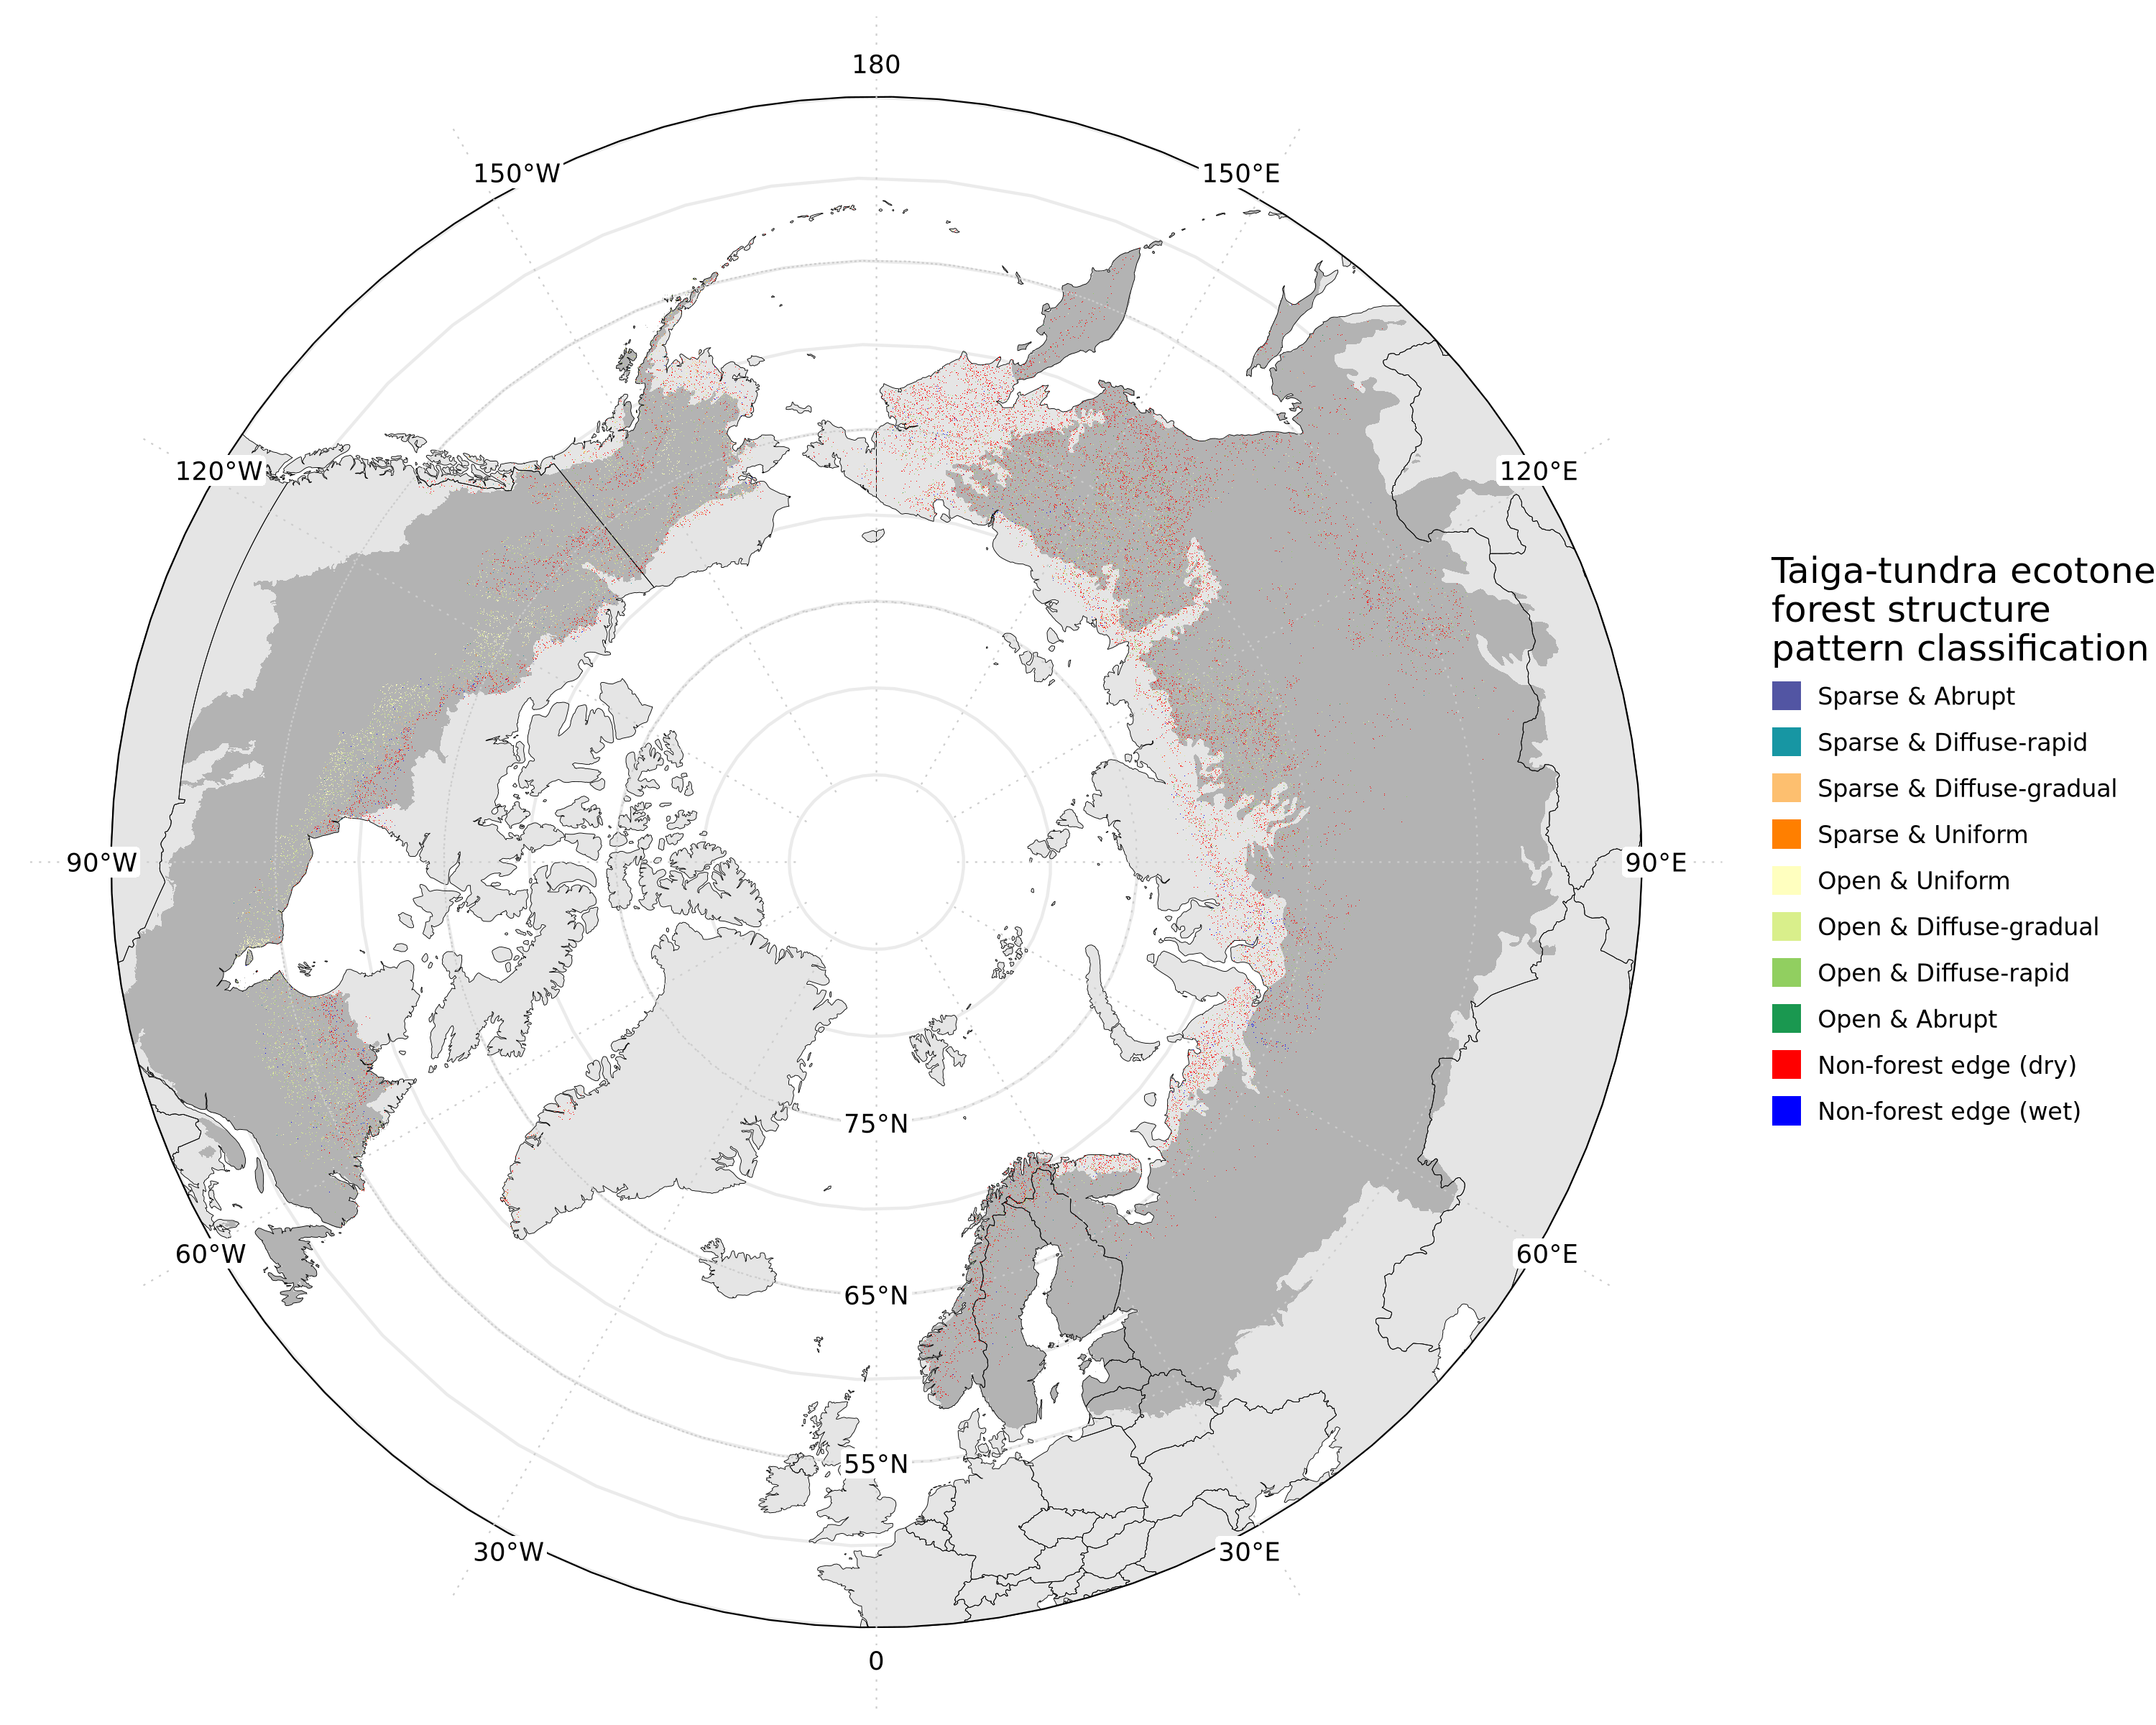

In [57]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 300)

m_boreal = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90),  
                     BOREAL_SHP_FN = wwf_circ_dis_fn
    ) + 
    theme(legend.text=element_text(size=rel(0.5))) #+

m_boreal + tte_layers